In [ ]:
!pip install geoopt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 1.6 MB/s eta 0:00:00


Epoch 0/100, Loss: 1.6273, Horizon Loss: 0.1249
Horizon Layer 1:
  Encoder Norm: 4.5753
  Decoder Norm: 3.2036
Horizon Layer 2:
  Encoder Norm: 4.6203
  Decoder Norm: 3.2002
Horizon Layer 3:
  Encoder Norm: 4.3832
  Decoder Norm: 3.2142


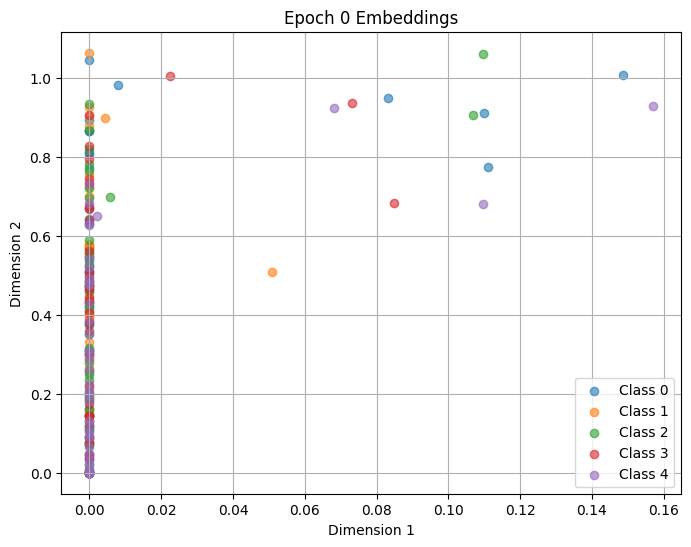

Epoch 10/100, Loss: 1.6029, Horizon Loss: 0.0716
Horizon Layer 1:
  Encoder Norm: 4.5721
  Decoder Norm: 3.2212
Horizon Layer 2:
  Encoder Norm: 4.6282
  Decoder Norm: 3.2106
Horizon Layer 3:
  Encoder Norm: 4.3795
  Decoder Norm: 3.2039


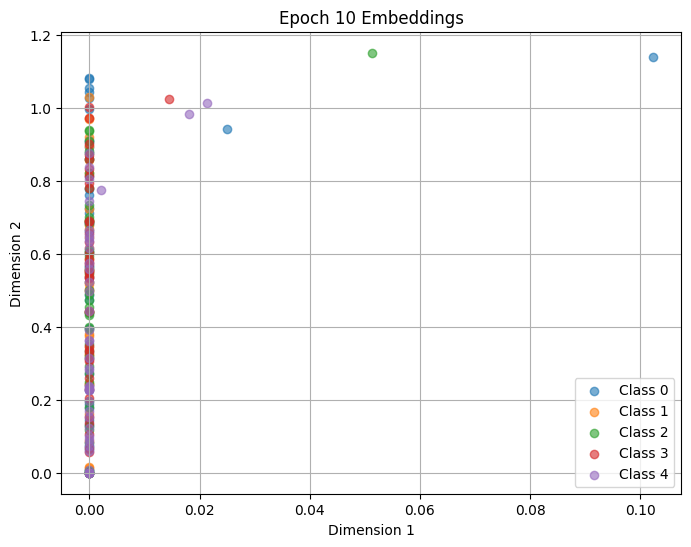

Epoch 20/100, Loss: 1.5819, Horizon Loss: 0.0633
Horizon Layer 1:
  Encoder Norm: 4.5714
  Decoder Norm: 3.2415
Horizon Layer 2:
  Encoder Norm: 4.6355
  Decoder Norm: 3.2223
Horizon Layer 3:
  Encoder Norm: 4.3742
  Decoder Norm: 3.2121


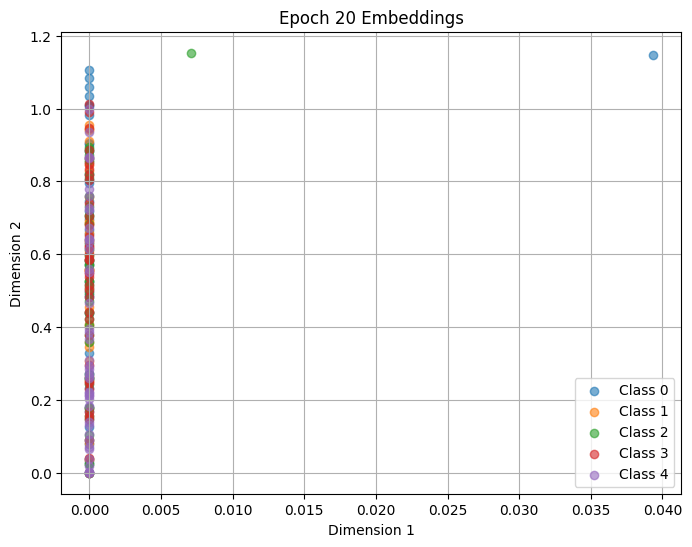

Epoch 30/100, Loss: 1.5608, Horizon Loss: 0.0659
Horizon Layer 1:
  Encoder Norm: 4.5759
  Decoder Norm: 3.2640
Horizon Layer 2:
  Encoder Norm: 4.6443
  Decoder Norm: 3.2392
Horizon Layer 3:
  Encoder Norm: 4.3721
  Decoder Norm: 3.2402


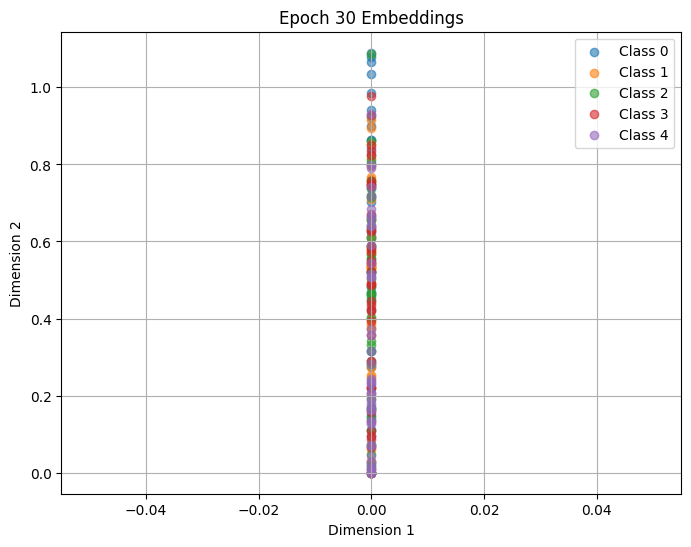

Epoch 40/100, Loss: 1.5378, Horizon Loss: 0.0738
Horizon Layer 1:
  Encoder Norm: 4.5820
  Decoder Norm: 3.2894
Horizon Layer 2:
  Encoder Norm: 4.6570
  Decoder Norm: 3.2639
Horizon Layer 3:
  Encoder Norm: 4.3754
  Decoder Norm: 3.2847


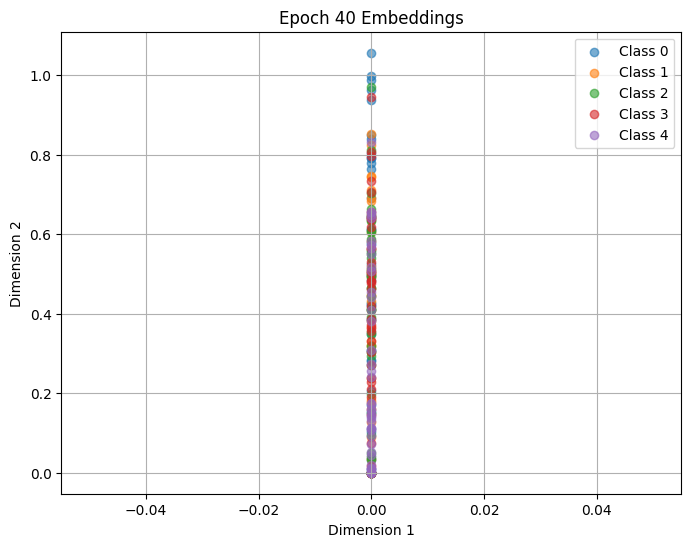

Epoch 50/100, Loss: 1.5113, Horizon Loss: 0.0850
Horizon Layer 1:
  Encoder Norm: 4.5900
  Decoder Norm: 3.3183
Horizon Layer 2:
  Encoder Norm: 4.6791
  Decoder Norm: 3.2974
Horizon Layer 3:
  Encoder Norm: 4.3832
  Decoder Norm: 3.3416


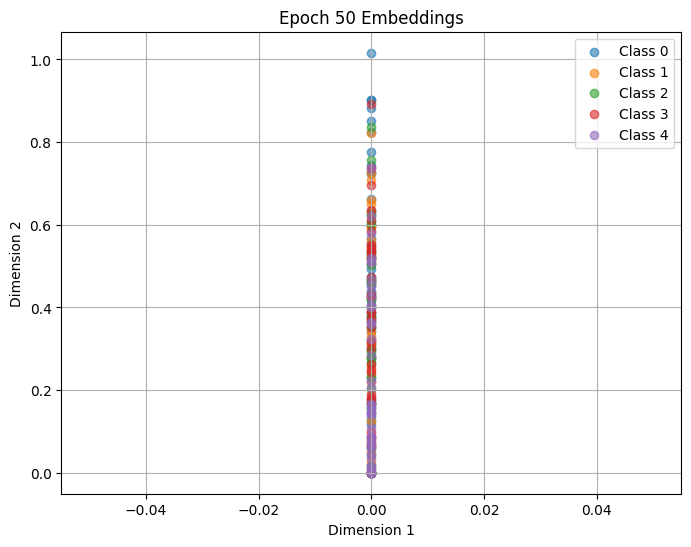

Epoch 60/100, Loss: 1.4792, Horizon Loss: 0.0964
Horizon Layer 1:
  Encoder Norm: 4.5987
  Decoder Norm: 3.3524
Horizon Layer 2:
  Encoder Norm: 4.7114
  Decoder Norm: 3.3448
Horizon Layer 3:
  Encoder Norm: 4.4002
  Decoder Norm: 3.4087


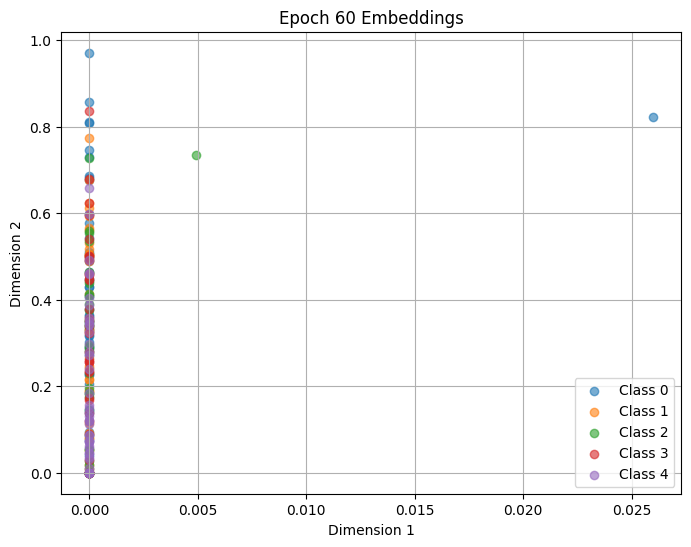

Epoch 70/100, Loss: 1.4417, Horizon Loss: 0.1119
Horizon Layer 1:
  Encoder Norm: 4.6106
  Decoder Norm: 3.3908
Horizon Layer 2:
  Encoder Norm: 4.7515
  Decoder Norm: 3.4027
Horizon Layer 3:
  Encoder Norm: 4.4273
  Decoder Norm: 3.4843


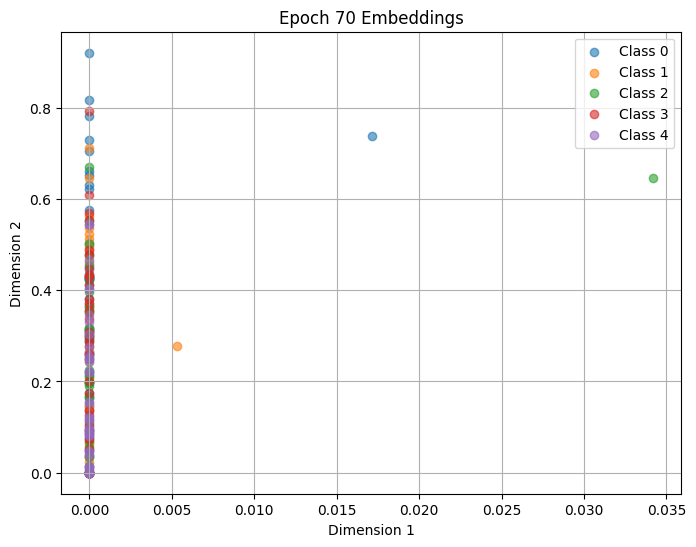

Epoch 80/100, Loss: 1.3992, Horizon Loss: 0.1249
Horizon Layer 1:
  Encoder Norm: 4.6262
  Decoder Norm: 3.4350
Horizon Layer 2:
  Encoder Norm: 4.7994
  Decoder Norm: 3.4650
Horizon Layer 3:
  Encoder Norm: 4.4541
  Decoder Norm: 3.5677


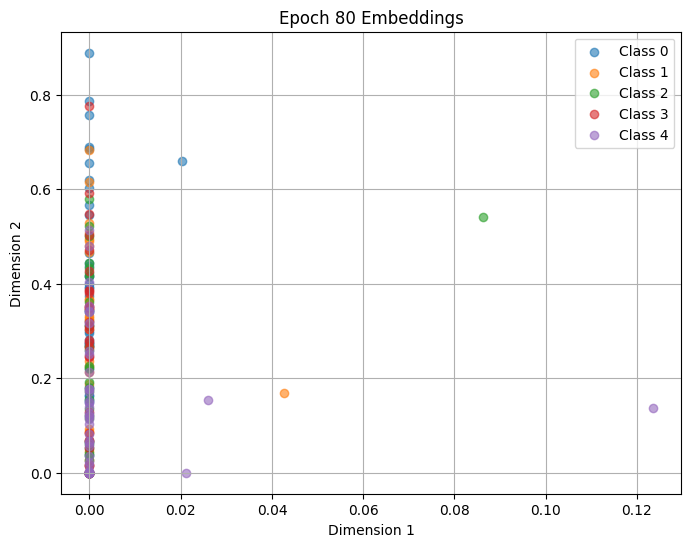

Epoch 90/100, Loss: 1.3511, Horizon Loss: 0.1415
Horizon Layer 1:
  Encoder Norm: 4.6429
  Decoder Norm: 3.4816
Horizon Layer 2:
  Encoder Norm: 4.8516
  Decoder Norm: 3.5256
Horizon Layer 3:
  Encoder Norm: 4.4871
  Decoder Norm: 3.6609


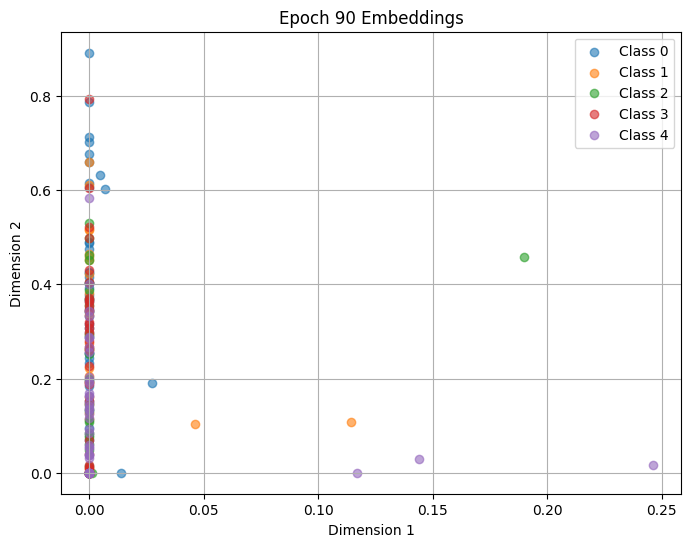

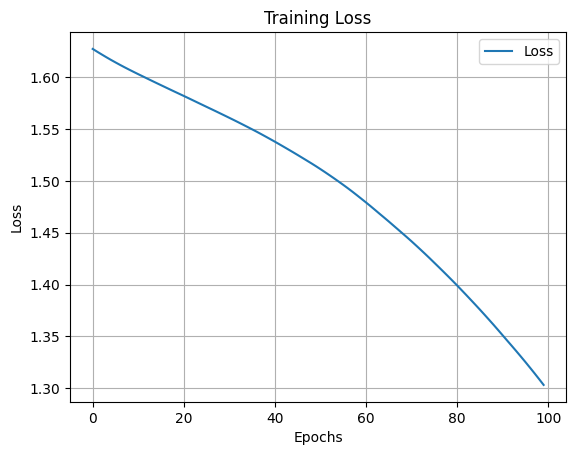

In [ ]:
import torch
import torch.nn.functional as F
import geoopt
from geoopt.manifolds import PoincareBall
from geoopt.manifolds.stereographic.math import mobius_matvec
import matplotlib.pyplot as plt
import numpy as np


class MobiusLinear(torch.nn.Module):
    def __init__(self, in_features, out_features, c=1.0):
        super(MobiusLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.c = c  # Keep c as a float
        self.weight = torch.nn.Parameter(torch.randn(out_features, in_features) / np.sqrt(in_features))
        self.bias = torch.nn.Parameter(torch.zeros(out_features))
        self.manifold = PoincareBall(c=c)

    def forward(self, x):
        # Ensure k is a tensor on the same device and dtype as x
        k = torch.tensor(-self.c, dtype=x.dtype, device=x.device)

        # Möbius matvec multiplication
        res = mobius_matvec(self.weight, x, k=k)

        # Möbius addition with bias
        res = self.manifold.mobius_add(res, self.bias)
        return res


class HyperbolicHorizonLayer(torch.nn.Module):
    def __init__(self, input_dim, output_dim, curvature=1.0):
        super(HyperbolicHorizonLayer, self).__init__()
        # Manifold representation of the horizon
        self.manifold = PoincareBall(c=curvature)

        # Learnable Möbius linear layers
        self.horizon_encoder = MobiusLinear(input_dim, output_dim, c=curvature)
        self.horizon_decoder = MobiusLinear(output_dim, input_dim, c=curvature)

        # Curvature parameter for horizon mapping
        self.curvature = curvature

    def mobius_activation(self, x, act_fn):
        tangent = self.manifold.logmap0(x)
        activated = act_fn(tangent)
        return self.manifold.expmap0(activated)

    def forward(self, x):
        # Map input to hyperbolic space
        x_hyperbolic = self.manifold.expmap0(x)

        # Encode data onto the hyperbolic horizon using Möbius linear layer
        encoded = self.horizon_encoder(x_hyperbolic)

        # Apply Möbius activation function
        horizon_transformed = self.mobius_activation(encoded, F.relu)

        # Decode from horizon back to original space
        decoded = self.horizon_decoder(horizon_transformed)

        # Map back to Euclidean space
        x_euclidean = self.manifold.logmap0(decoded)

        return x_euclidean, horizon_transformed


class HyperbolicHorizonNetwork(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_horizons=3):
        super(HyperbolicHorizonNetwork, self).__init__()

        # Multiple hyperbolic horizon layers
        self.horizon_layers = torch.nn.ModuleList([
            HyperbolicHorizonLayer(input_dim, hidden_dim, curvature=1.0 / (i+1))
            for i in range(num_horizons)
        ])

        # Final classification layer
        self.classifier = torch.nn.Linear(input_dim, output_dim)

    def forward(self, x):
        # Propagate through multiple hyperbolic horizons
        for horizon_layer in self.horizon_layers:
            x, embeddings = horizon_layer(x)

        # Save the final embeddings before classification
        self.embeddings = embeddings.clone()

        # Final classification
        return self.classifier(x)


def visualize_embeddings(data, labels, title="Embeddings in Hyperbolic Space"):
    with torch.no_grad():
        plt.figure(figsize=(8, 6))
        for label in torch.unique(labels):
            idx = (labels == label).nonzero(as_tuple=True)[0]
            plt.scatter(data[idx, 0], data[idx, 1], label=f"Class {label.item()}", alpha=0.6)
        plt.title(title)
        plt.xlabel("Dimension 1")
        plt.ylabel("Dimension 2")
        plt.legend()
        plt.grid()
        plt.show()


def train_hyperbolic_horizon_network(model, data, labels, epochs=100, lr=0.001):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = torch.nn.CrossEntropyLoss()
    all_losses = []
    lambda_horizon = 0.1  # Regularization parameter for horizon loss

    for epoch in range(epochs):
        optimizer.zero_grad()

        # Forward pass
        output = model(data)
        loss = criterion(output, labels)

        # Horizon loss to encourage norms close to 1
        embeddings = model.embeddings
        norms = embeddings.norm(dim=1)
        horizon_loss = torch.mean((norms - 1.0)**2)

        # Total loss
        total_loss = loss + lambda_horizon * horizon_loss
        all_losses.append(total_loss.item())

        # Backward pass and optimization
        total_loss.backward()
        optimizer.step()

        # Log loss and layer stats
        if epoch % 10 == 0:
            print(f"Epoch {epoch}/{epochs}, Loss: {total_loss.item():.4f}, Horizon Loss: {horizon_loss.item():.4f}")
            for i, layer in enumerate(model.horizon_layers):
                print(f"Horizon Layer {i+1}:")
                print(f"  Encoder Norm: {torch.norm(layer.horizon_encoder.weight).item():.4f}")
                print(f"  Decoder Norm: {torch.norm(layer.horizon_decoder.weight).item():.4f}")

            # Visualize embeddings
            embeddings = model.embeddings.detach()
            visualize_embeddings(embeddings, labels, title=f"Epoch {epoch} Embeddings")

    # Final loss plot
    plt.plot(all_losses, label="Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.grid()
    plt.legend()
    plt.show()


def main():
    # Simulation parameters
    input_dim = 10
    hidden_dim = 20
    output_dim = 5
    num_samples = 200

    # Generate synthetic data
    data = torch.randn(num_samples, input_dim)
    labels = torch.randint(0, output_dim, (num_samples,))

    # Initialize hyperbolic horizon network
    model = HyperbolicHorizonNetwork(
        input_dim=input_dim,
        hidden_dim=hidden_dim,
        output_dim=output_dim
    )

    # Train the network
    train_hyperbolic_horizon_network(model, data, labels)


if __name__ == "__main__":
    main()

Epoch 0/100, Loss: 1.7254, Horizon Loss: 0.0854
Mean Embedding Norm: 1.1971, Std: 0.2163
Horizon Layer 1:
  Encoder Norm: 4.4159
  Decoder Norm: 3.1381
Horizon Layer 2:
  Encoder Norm: 4.4706
  Decoder Norm: 3.1921
Horizon Layer 3:
  Encoder Norm: 4.9311
  Decoder Norm: 3.3328
Epoch 10/100, Loss: 1.6595, Horizon Loss: 0.0395
Mean Embedding Norm: 1.0502, Std: 0.1927
Horizon Layer 1:
  Encoder Norm: 4.4081
  Decoder Norm: 3.1064
Horizon Layer 2:
  Encoder Norm: 4.4577
  Decoder Norm: 3.1679
Horizon Layer 3:
  Encoder Norm: 4.8866
  Decoder Norm: 3.3255
Epoch 20/100, Loss: 1.6218, Horizon Loss: 0.0211
Mean Embedding Norm: 1.0220, Std: 0.1440
Horizon Layer 1:
  Encoder Norm: 4.4060
  Decoder Norm: 3.0930
Horizon Layer 2:
  Encoder Norm: 4.4543
  Decoder Norm: 3.1596
Horizon Layer 3:
  Encoder Norm: 4.8710
  Decoder Norm: 3.3317
Epoch 30/100, Loss: 1.5972, Horizon Loss: 0.0146
Mean Embedding Norm: 1.0259, Std: 0.1182
Horizon Layer 1:
  Encoder Norm: 4.4061
  Decoder Norm: 3.0882
Horizon Lay

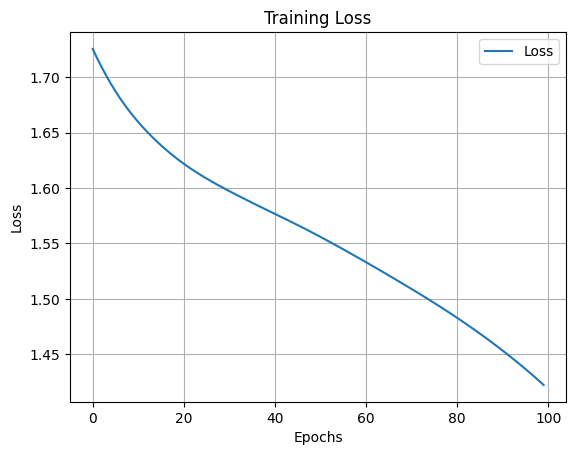

In [ ]:
import torch
import torch.nn.functional as F
import geoopt
from geoopt.manifolds import PoincareBall
from geoopt.manifolds.stereographic.math import mobius_matvec
import matplotlib.pyplot as plt
import numpy as np


class MobiusLinear(torch.nn.Module):
    def __init__(self, in_features, out_features, c=1.0):
        super(MobiusLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.c = c  # Keep c as a float
        self.weight = torch.nn.Parameter(torch.randn(out_features, in_features) / np.sqrt(in_features))
        self.bias = torch.nn.Parameter(torch.zeros(out_features))
        self.manifold = PoincareBall(c=c)

    def forward(self, x):
        # Ensure k is a tensor on the same device and dtype as x
        k = torch.tensor(-self.c, dtype=x.dtype, device=x.device)

        # Möbius matvec multiplication
        res = mobius_matvec(self.weight, x, k=k)

        # Möbius addition with bias
        res = self.manifold.mobius_add(res, self.bias)
        return res


class HyperbolicHorizonLayer(torch.nn.Module):
    def __init__(self, input_dim, output_dim, curvature=1.0):
        super(HyperbolicHorizonLayer, self).__init__()
        # Manifold representation of the horizon
        self.manifold = PoincareBall(c=curvature)

        # Learnable Möbius linear layers
        self.horizon_encoder = MobiusLinear(input_dim, output_dim, c=curvature)
        self.horizon_decoder = MobiusLinear(output_dim, input_dim, c=curvature)

        # Curvature parameter for horizon mapping
        self.curvature = curvature

    def mobius_activation(self, x, act_fn):
        tangent = self.manifold.logmap0(x)
        activated = act_fn(tangent)
        return self.manifold.expmap0(activated)

    def forward(self, x):
        # Map input to hyperbolic space
        x_hyperbolic = self.manifold.expmap0(x)

        # Encode data onto the hyperbolic horizon using Möbius linear layer
        encoded = self.horizon_encoder(x_hyperbolic)

        # Apply Möbius activation function using tanh
        horizon_transformed = self.mobius_activation(encoded, torch.tanh)

        # Remove explicit normalization
        # epsilon = 1e-5  # Remove this line
        # norms = horizon_transformed.norm(dim=1, keepdim=True)
        # horizon_transformed = horizon_transformed / norms * (1 - epsilon)

        # Decode from horizon back to original space
        decoded = self.horizon_decoder(horizon_transformed)

        # Map back to Euclidean space
        x_euclidean = self.manifold.logmap0(decoded)

        return x_euclidean, horizon_transformed


class HyperbolicHorizonNetwork(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_horizons=3):
        super(HyperbolicHorizonNetwork, self).__init__()

        # Multiple hyperbolic horizon layers
        self.horizon_layers = torch.nn.ModuleList([
            HyperbolicHorizonLayer(input_dim, hidden_dim, curvature=1.0 / (i+1))
            for i in range(num_horizons)
        ])

        # Final classification layer
        self.classifier = torch.nn.Linear(input_dim, output_dim)

    def forward(self, x):
        # Propagate through multiple hyperbolic horizons
        for horizon_layer in self.horizon_layers:
            x, embeddings = horizon_layer(x)

        # Save the final embeddings before classification
        self.embeddings = embeddings.clone()

        # Final classification
        return self.classifier(x)


def visualize_embeddings(data, labels, title="Embeddings in Hyperbolic Space"):
    with torch.no_grad():
        plt.figure(figsize=(8, 6))
        for label in torch.unique(labels):
            idx = (labels == label).nonzero(as_tuple=True)[0]
            plt.scatter(data[idx, 0], data[idx, 1], label=f"Class {label.item()}", alpha=0.6)
        plt.title(title)
        plt.xlabel("Dimension 1")
        plt.ylabel("Dimension 2")
        plt.legend()
        plt.grid()
        plt.show()


def train_hyperbolic_horizon_network(model, data, labels, epochs=100, lr=0.001):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = torch.nn.CrossEntropyLoss()
    all_losses = []
    lambda_horizon = 1.0  # Adjust as needed

    for epoch in range(epochs):
        optimizer.zero_grad()

        # Forward pass
        output = model(data)
        loss = criterion(output, labels)

        # Horizon loss to encourage norms close to 1
        embeddings = model.embeddings
        norms = embeddings.norm(dim=1)
        horizon_loss = torch.mean((norms - 1.0)**2)

        # Total loss
        total_loss = loss + lambda_horizon * horizon_loss
        all_losses.append(total_loss.item())

        # Backward pass and optimization
        total_loss.backward()
        optimizer.step()

        # Log loss and layer stats
        if epoch % 10 == 0:
            mean_norm = norms.mean().item()
            std_norm = norms.std().item()
            print(f"Epoch {epoch}/{epochs}, Loss: {total_loss.item():.4f}, Horizon Loss: {horizon_loss.item():.4f}")
            print(f"Mean Embedding Norm: {mean_norm:.4f}, Std: {std_norm:.4f}")
            for i, layer in enumerate(model.horizon_layers):
                print(f"Horizon Layer {i+1}:")
                print(f"  Encoder Norm: {torch.norm(layer.horizon_encoder.weight).item():.4f}")
                print(f"  Decoder Norm: {torch.norm(layer.horizon_decoder.weight).item():.4f}")

            # Visualize embeddings (optional)
            # embeddings = model.embeddings.detach()
            # visualize_embeddings(embeddings, labels, title=f"Epoch {epoch} Embeddings")

    # Final loss plot
    plt.plot(all_losses, label="Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.grid()
    plt.legend()
    plt.show()


def main():
    # Simulation parameters
    input_dim = 10
    hidden_dim = 20
    output_dim = 5
    num_samples = 200

    # Generate synthetic data
    data = torch.randn(num_samples, input_dim)
    labels = torch.randint(0, output_dim, (num_samples,))

    # Initialize hyperbolic horizon network
    model = HyperbolicHorizonNetwork(
        input_dim=input_dim,
        hidden_dim=hidden_dim,
        output_dim=output_dim
    )

    # Train the network
    train_hyperbolic_horizon_network(model, data, labels)


if __name__ == "__main__":
    main()

Epoch 0/100, Total Loss: 1.8060, Horizon Loss: 0.1480
Mean Embedding Norm: 1.3438, Std: 0.1732
Epoch 10/100, Total Loss: 1.7451, Horizon Loss: 0.1320
Mean Embedding Norm: 1.3087, Std: 0.1922
Epoch 20/100, Total Loss: 1.7299, Horizon Loss: 0.1421
Mean Embedding Norm: 1.3198, Std: 0.1999
Epoch 30/100, Total Loss: 1.7320, Horizon Loss: 0.1618
Mean Embedding Norm: 1.3528, Std: 0.1937
Epoch 40/100, Total Loss: 1.7374, Horizon Loss: 0.1835
Mean Embedding Norm: 1.3889, Std: 0.1801
Epoch 50/100, Total Loss: 1.7432, Horizon Loss: 0.2071
Mean Embedding Norm: 1.4255, Std: 0.1618
Epoch 60/100, Total Loss: 1.7507, Horizon Loss: 0.2342
Mean Embedding Norm: 1.4634, Std: 0.1397
Epoch 70/100, Total Loss: 1.7569, Horizon Loss: 0.2620
Mean Embedding Norm: 1.4969, Std: 0.1230
Epoch 80/100, Total Loss: 1.7604, Horizon Loss: 0.2906
Mean Embedding Norm: 1.5287, Std: 0.1057
Epoch 90/100, Total Loss: 1.7629, Horizon Loss: 0.3208
Mean Embedding Norm: 1.5588, Std: 0.0927


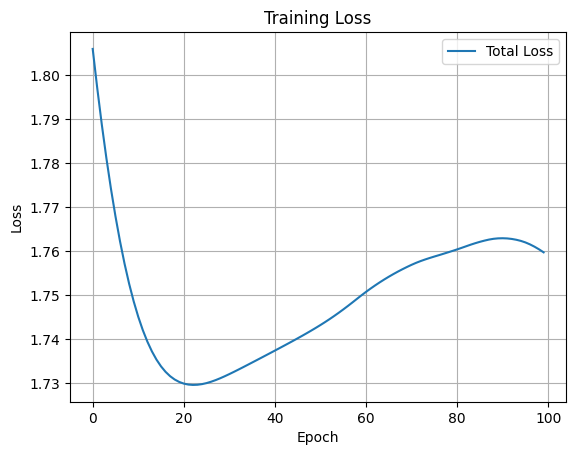

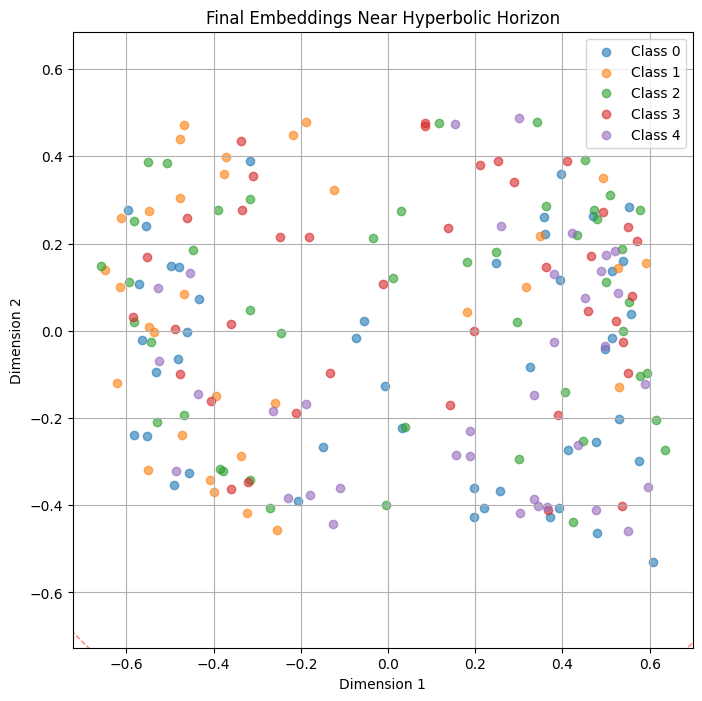

In [ ]:
import torch
import torch.nn.functional as F
import geoopt
from geoopt.manifolds import PoincareBall
from geoopt.manifolds.stereographic.math import mobius_matvec
import matplotlib.pyplot as plt
import numpy as np


class MobiusLinear(torch.nn.Module):
    def __init__(self, in_features, out_features, c=1.0):
        super(MobiusLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.c = c
        self.weight = torch.nn.Parameter(torch.randn(out_features, in_features) / np.sqrt(in_features))
        self.bias = torch.nn.Parameter(torch.zeros(out_features))
        self.manifold = PoincareBall(c=c)

    def forward(self, x):
        k = torch.tensor(-self.c, dtype=x.dtype, device=x.device)
        res = mobius_matvec(self.weight, x, k=k)
        res = self.manifold.mobius_add(res, self.bias)
        return res


class HyperbolicHorizonLayer(torch.nn.Module):
    def __init__(self, input_dim, output_dim, curvature=1.0):
        super(HyperbolicHorizonLayer, self).__init__()
        self.manifold = PoincareBall(c=curvature)
        self.horizon_encoder = MobiusLinear(input_dim, output_dim, c=curvature)
        self.horizon_decoder = MobiusLinear(output_dim, input_dim, c=curvature)

    def mobius_activation(self, x, act_fn):
        tangent = self.manifold.logmap0(x)
        activated = act_fn(tangent)
        return self.manifold.expmap0(activated)

    def forward(self, x):
        x_hyperbolic = self.manifold.expmap0(x)
        encoded = self.horizon_encoder(x_hyperbolic)
        horizon_transformed = self.mobius_activation(encoded, torch.tanh)
        decoded = self.horizon_decoder(horizon_transformed)
        x_euclidean = self.manifold.logmap0(decoded)
        return x_euclidean, horizon_transformed


class HyperbolicHorizonNetwork(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_horizons=3):
        super(HyperbolicHorizonNetwork, self).__init__()
        self.horizon_layers = torch.nn.ModuleList([
            HyperbolicHorizonLayer(input_dim, hidden_dim, curvature=1.0 / (i+1))
            for i in range(num_horizons)
        ])
        self.classifier = torch.nn.Linear(input_dim, output_dim)

    def forward(self, x, return_embeddings=False):
        for horizon_layer in self.horizon_layers:
            x, embeddings = horizon_layer(x)
        if return_embeddings:
            return embeddings
        return self.classifier(x)


def visualize_embeddings(data, labels, title="Embeddings in Hyperbolic Space"):
    with torch.no_grad():
        norms = data.norm(dim=1)
        plt.figure(figsize=(8, 8))
        for label in torch.unique(labels):
            idx = (labels == label).nonzero(as_tuple=True)[0]
            plt.scatter(
                data[idx, 0].cpu(),
                data[idx, 1].cpu(),
                label=f"Class {label.item()}",
                alpha=0.6
            )
        circle = plt.Circle((0, 0), 1.0, color='r', fill=False, linestyle='--', alpha=0.5)
        plt.gca().add_artist(circle)
        plt.title(title)
        plt.xlabel("Dimension 1")
        plt.ylabel("Dimension 2")
        plt.legend()
        plt.axis("equal")
        plt.grid()
        plt.show()


def train_hyperbolic_horizon_network(model, data, labels, epochs=100, lr=0.001):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = torch.nn.CrossEntropyLoss()
    all_losses = []

    for epoch in range(epochs):
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, labels)

        # Compute embeddings and enforce holographic boundary proximity
        with torch.no_grad():
            embeddings = model(data, return_embeddings=True)
        norms = embeddings.norm(dim=1)
        horizon_loss = torch.mean((norms - 1.0)**2)

        # Adjust loss based on proximity to hyperbolic boundary
        total_loss = loss + 1.0 * horizon_loss
        total_loss.backward()
        optimizer.step()
        all_losses.append(total_loss.item())

        # Log every 10 epochs
        if epoch % 10 == 0:
            print(f"Epoch {epoch}/{epochs}, Total Loss: {total_loss.item():.4f}, Horizon Loss: {horizon_loss.item():.4f}")
            print(f"Mean Embedding Norm: {norms.mean().item():.4f}, Std: {norms.std().item():.4f}")

    # Loss plot
    plt.plot(all_losses, label="Total Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.grid()
    plt.legend()
    plt.show()


def main():
    input_dim = 10
    hidden_dim = 20
    output_dim = 5
    num_samples = 200

    # Generate synthetic data
    data = torch.randn(num_samples, input_dim)
    labels = torch.randint(0, output_dim, (num_samples,))

    model = HyperbolicHorizonNetwork(input_dim=input_dim, hidden_dim=hidden_dim, output_dim=output_dim)
    train_hyperbolic_horizon_network(model, data, labels)

    # Evaluate and visualize final embeddings
    model.eval()
    with torch.no_grad():
        embeddings = model(data, return_embeddings=True)
    visualize_embeddings(embeddings, labels, title="Final Embeddings Near Hyperbolic Horizon")


if __name__ == "__main__":
    main()

Epoch 0/100, Total Loss: 1.7407, Horizon Loss: 0.1557
Mean Embedding Norm: 1.3715, Std: 0.1332
Epoch 10/100, Total Loss: 1.6768, Horizon Loss: 0.1426
Mean Embedding Norm: 1.3541, Std: 0.1316
Epoch 20/100, Total Loss: 1.6468, Horizon Loss: 0.1491
Mean Embedding Norm: 1.3636, Std: 0.1303
Epoch 30/100, Total Loss: 1.6293, Horizon Loss: 0.1676
Mean Embedding Norm: 1.3896, Std: 0.1259
Epoch 40/100, Total Loss: 1.6170, Horizon Loss: 0.1927
Mean Embedding Norm: 1.4227, Std: 0.1184
Epoch 50/100, Total Loss: 1.6063, Horizon Loss: 0.2167
Mean Embedding Norm: 1.4527, Std: 0.1091
Epoch 60/100, Total Loss: 1.5941, Horizon Loss: 0.2372
Mean Embedding Norm: 1.4770, Std: 0.0982
Epoch 70/100, Total Loss: 1.5810, Horizon Loss: 0.2576
Mean Embedding Norm: 1.4990, Std: 0.0926
Epoch 80/100, Total Loss: 1.5656, Horizon Loss: 0.2782
Mean Embedding Norm: 1.5197, Std: 0.0903
Epoch 90/100, Total Loss: 1.5474, Horizon Loss: 0.2995
Mean Embedding Norm: 1.5402, Std: 0.0880


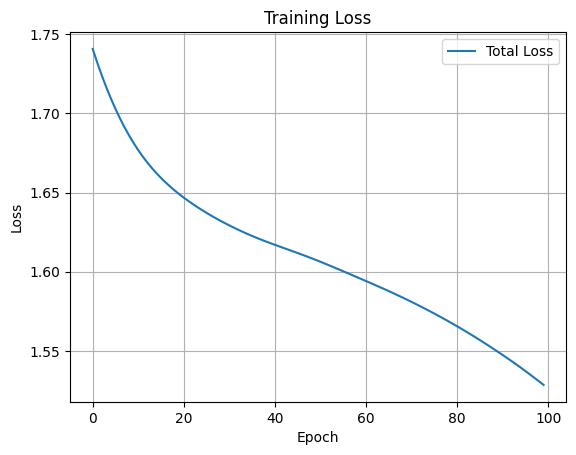

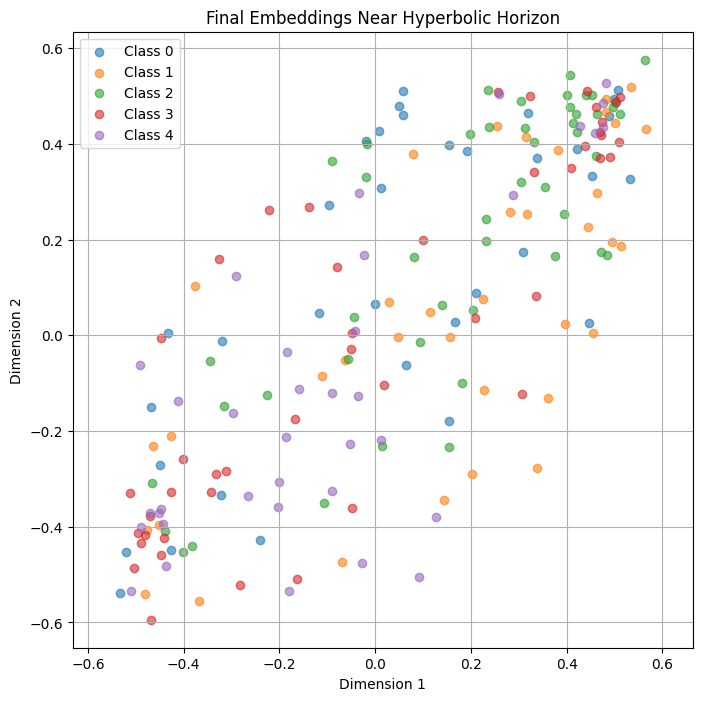

In [ ]:
import torch
import torch.nn.functional as F
import geoopt
from geoopt.manifolds import PoincareBall
from geoopt.manifolds.stereographic.math import mobius_matvec
import matplotlib.pyplot as plt
import numpy as np


class MobiusLinear(torch.nn.Module):
    def __init__(self, in_features, out_features, c=1.0):
        super(MobiusLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.c = c
        self.weight = torch.nn.Parameter(torch.randn(out_features, in_features) / np.sqrt(in_features))
        self.bias = torch.nn.Parameter(torch.zeros(out_features))
        self.manifold = PoincareBall(c=c)

    def forward(self, x):
        k = torch.tensor(-self.c, dtype=x.dtype, device=x.device)
        res = mobius_matvec(self.weight, x, k=k)
        res = self.manifold.mobius_add(res, self.bias)
        return res


class HyperbolicHorizonLayer(torch.nn.Module):
    def __init__(self, input_dim, output_dim, curvature=1.0):
        super(HyperbolicHorizonLayer, self).__init__()
        self.manifold = PoincareBall(c=curvature)
        self.encoder = MobiusLinear(input_dim, output_dim, c=curvature)
        self.decoder = MobiusLinear(output_dim, input_dim, c=curvature)

    def mobius_activation(self, x, act_fn):
        tangent = self.manifold.logmap0(x)
        activated = act_fn(tangent)
        return self.manifold.expmap0(activated)

    def forward(self, x):
        x_hyperbolic = self.manifold.expmap0(x)  # Map input to hyperbolic space
        encoded = self.encoder(x_hyperbolic)
        horizon_transformed = self.mobius_activation(encoded, torch.tanh)
        decoded = self.decoder(horizon_transformed)
        x_euclidean = self.manifold.logmap0(decoded)
        return x_euclidean, horizon_transformed


class HyperbolicHorizonNetwork(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_horizons=3):
        super(HyperbolicHorizonNetwork, self).__init__()
        self.horizon_layers = torch.nn.ModuleList([
            HyperbolicHorizonLayer(input_dim, hidden_dim, curvature=1.0 / (i + 1))
            for i in range(num_horizons)
        ])
        self.classifier = torch.nn.Linear(input_dim, output_dim)

    def forward(self, x, return_embeddings=False):
        for horizon_layer in self.horizon_layers:
            x, embeddings = horizon_layer(x)
        if return_embeddings:
            return embeddings
        return self.classifier(x)


def visualize_embeddings(data, labels, title="Embeddings in Hyperbolic Space"):
    with torch.no_grad():
        norms = data.norm(dim=1)
        plt.figure(figsize=(8, 8))
        for label in torch.unique(labels):
            idx = (labels == label).nonzero(as_tuple=True)[0]
            plt.scatter(
                data[idx, 0].cpu(),
                data[idx, 1].cpu(),
                label=f"Class {label.item()}",
                alpha=0.6
            )
        circle = plt.Circle((0, 0), 1.0, color='r', fill=False, linestyle='--', alpha=0.5)
        plt.gca().add_artist(circle)
        plt.title(title)
        plt.xlabel("Dimension 1")
        plt.ylabel("Dimension 2")
        plt.legend()
        plt.axis("equal")
        plt.grid()
        plt.show()


def train_hyperbolic_horizon_network(model, data, labels, epochs=100, lr=0.001):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = torch.nn.CrossEntropyLoss()
    all_losses = []

    for epoch in range(epochs):
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, labels)

        # Compute embeddings and enforce holographic boundary proximity
        with torch.no_grad():
            embeddings = model(data, return_embeddings=True)
        norms = embeddings.norm(dim=1)
        horizon_loss = torch.mean((norms - 1.0) ** 2)  # Encourage embeddings near the hyperbolic horizon

        # Adjust loss based on proximity to hyperbolic boundary
        total_loss = loss + 0.5 * horizon_loss  # Tunable weight for horizon loss
        total_loss.backward()
        optimizer.step()
        all_losses.append(total_loss.item())

        # Log every 10 epochs
        if epoch % 10 == 0:
            print(f"Epoch {epoch}/{epochs}, Total Loss: {total_loss.item():.4f}, Horizon Loss: {horizon_loss.item():.4f}")
            print(f"Mean Embedding Norm: {norms.mean().item():.4f}, Std: {norms.std().item():.4f}")

    # Loss plot
    plt.plot(all_losses, label="Total Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.grid()
    plt.legend()
    plt.show()


def main():
    input_dim = 10
    hidden_dim = 20
    output_dim = 5
    num_samples = 200

    # Generate synthetic data
    data = torch.randn(num_samples, input_dim)
    labels = torch.randint(0, output_dim, (num_samples,))

    model = HyperbolicHorizonNetwork(input_dim=input_dim, hidden_dim=hidden_dim, output_dim=output_dim)
    train_hyperbolic_horizon_network(model, data, labels)

    # Evaluate and visualize final embeddings
    model.eval()
    with torch.no_grad():
        embeddings = model(data, return_embeddings=True)
    visualize_embeddings(embeddings, labels, title="Final Embeddings Near Hyperbolic Horizon")


if __name__ == "__main__":
    main()